# Dataset Analysis — PHM 2010 Challenge

**Machine:** Röders Tech RFM760 | **Material:** Inconel 718 | **fs = 50,000 Hz**

**Dataset URL:** https://www.kaggle.com/datasets/rabahba/phm-data-challenge-2010

This notebook provides a thorough analysis of the PHM 2010 benchmark dataset:
- Raw signal inspection (temporal)
- Spectral analysis (FFT, Welch PSD)
- Wear evolution and wear rate
- Statistical feature extraction (time + frequency domains)
- Correlation analysis
- ML model: Random Forest with Leave-One-Tool-Out validation
- Feature importance

## 0. Setup & Configuration

In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import skew, kurtosis, pearsonr
from scipy.fft import fft, fftfreq
from scipy.signal import welch
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings('ignore')

# ── CONFIGURATION ────────────────────────────────────────────
# Try common locations so the notebook works from either project root or notebook folder
DATASET_CANDIDATES = [
    'dataset_4',
    '../dataset_4',
    os.path.join(os.getcwd(), 'dataset_4'),
    os.path.join(os.getcwd(), '..', 'dataset_4'),
]
DATASET_PATH = next((p for p in DATASET_CANDIDATES if os.path.isdir(p)), 'dataset_4')

FS              = 50_000                 # Sampling frequency (Hz)
VB_EOL          = 0.300                  # End-of-life threshold (mm)
VB_WARN         = 0.200                  # Warning threshold (mm)
TOOLS_LABELED   = ['c1', 'c4', 'c6']    # Only tools with wear labels
COL_NAMES       = ['force_x','force_y','force_z','vib_x','vib_y','vib_z','ae']

# Characteristic frequencies
F_SPINDLE       = 10400 / 60             # 173.3 Hz
F_TOOTH         = F_SPINDLE * 3          # 520.0 Hz (3-flute)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('✅ Configuration loaded')
print(f'   Dataset path : {os.path.abspath(DATASET_PATH)}')
print(f'   Spindle frequency : {F_SPINDLE:.1f} Hz')
print(f'   Tooth pass frequency : {F_TOOTH:.1f} Hz')
print(f'   Nyquist limit : {FS//2:,} Hz')

✅ Configuration loaded
   Dataset path : c:\unity\stage\dataset_4
   Spindle frequency : 173.3 Hz
   Tooth pass frequency : 520.0 Hz
   Nyquist limit : 25,000 Hz


## 1. Data Loading

In [2]:
def load_wear(tool):
    """Load wear file for a given tool. Returns DataFrame with [passe, vb_mean]."""
    for path in [
        os.path.join(DATASET_PATH, 'wear', f'{tool}_wear.csv'),
        os.path.join(DATASET_PATH, tool, f'{tool}_wear.csv'),
        os.path.join(DATASET_PATH, f'{tool}_wear.csv'),
    ]:
        if os.path.exists(path):
            # Read robustly: coerce to numeric so header text (if present) is discarded
            df_raw = pd.read_csv(path, header=None)
            df_num = df_raw.apply(pd.to_numeric, errors='coerce').dropna(how='all')
            if df_num.shape[1] >= 4:
                df = df_num.iloc[:, :4].copy()
                df.columns = ['passe','vb1','vb2','vb3']
                df['vb_mean'] = df[['vb1','vb2','vb3']].mean(axis=1)
            elif df_num.shape[1] >= 2:
                df = df_num.iloc[:, :2].copy()
                df.columns = ['passe','vb_mean']
            else:
                raise ValueError(f'Unexpected wear format in {path}')

            # Clean possible NaNs introduced by malformed rows
            df = df.dropna(subset=['passe', 'vb_mean']).reset_index(drop=True)
            df['passe'] = df['passe'].astype(int)

            # Convert from 10^-3 mm if values look too large
            if df['vb_mean'].max() > 10:
                df['vb_mean'] = df['vb_mean'] / 1000.0
            return df
    raise FileNotFoundError(f'Wear file not found for {tool}')

def load_signal(filepath):
    return pd.read_csv(filepath, header=None, names=COL_NAMES)

# Load wear data
wear = {}
for t in TOOLS_LABELED:
    try:
        wear[t] = load_wear(t)
        print(f'✅ {t.upper()}: {len(wear[t])} passes | VB 0→{wear[t]["vb_mean"].max():.3f} mm')
    except Exception as e:
        print(f'❌ {t}: {e}')

# Preview one signal file (exclude wear files and search recursively)
samples_c1 = sorted([
    f for f in glob.glob(os.path.join(DATASET_PATH, 'c1', '**', '*.csv'), recursive=True)
    if 'wear' not in os.path.basename(f).lower()
])
if samples_c1:
    sig_ex = load_signal(samples_c1[0])
    n_pts  = len(sig_ex)
    dur_s  = n_pts / FS
    print(f'\n📋 Signal example (C1, pass 1):')
    print(f'   {n_pts:,} data points | {dur_s:.2f}s duration | {n_pts*7/1e6:.1f} MB per file (float64)')
    display(sig_ex.describe().round(4))
else:
    print('❌ No C1 signal files found — check DATASET_PATH')

✅ C1: 315 passes | VB 0→0.165 mm
✅ C4: 315 passes | VB 0→0.203 mm
✅ C6: 315 passes | VB 0→0.216 mm

📋 Signal example (C1, pass 1):
   127,399 data points | 2.55s duration | 0.9 MB per file (float64)


,force_x,force_y,force_z,vib_x,vib_y,vib_z,ae
count,127399.0000,127399.0000,127399.0000,127399.0000,127399.0000,127399.0000,127399.0000
mean,0.4009,0.6295,0.7051,0.0093,0.0136,0.0182,-0.0001
std,0.8425,1.6360,1.1275,0.0763,0.0763,0.0766,0.0022
min,-2.5010,-12.0510,-3.2430,-0.3160,-0.3170,-0.3150,-0.0050
25%,-0.1980,-0.3420,-0.0670,-0.0410,-0.0370,-0.0320,-0.0020
50%,0.3770,0.6410,0.7080,0.0090,0.0140,0.0180,0.0000
75%,0.9840,1.6350,1.4830,0.0600,0.0640,0.0690,0.0010
max,3.7440,10.7240,4.5600,0.3300,0.3470,0.3540,0.0100


## 2. Wear Evolution Analysis

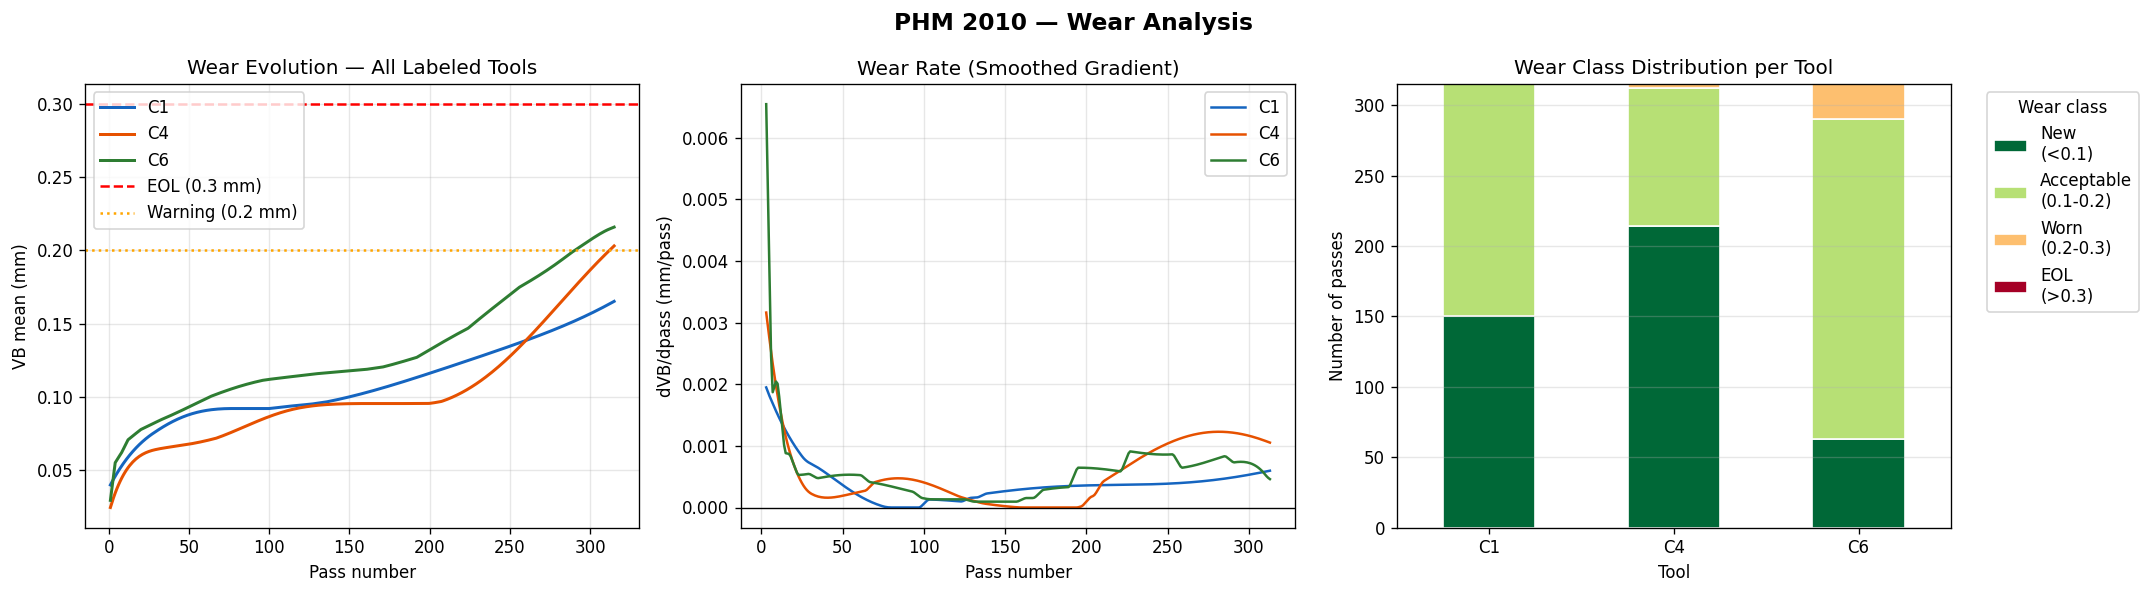

In [3]:
COLORS = {'c1':'#1565C0','c4':'#E65100','c6':'#2E7D32'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 2a. VB over passes ---
for t, df_w in wear.items():
    axes[0].plot(df_w['passe'], df_w['vb_mean'],
                 color=COLORS[t], label=t.upper(), linewidth=1.8)
axes[0].axhline(VB_EOL,  color='red',    linestyle='--', linewidth=1.5, label=f'EOL ({VB_EOL} mm)')
axes[0].axhline(VB_WARN, color='orange', linestyle=':',  linewidth=1.5, label=f'Warning ({VB_WARN} mm)')
axes[0].set_xlabel('Pass number'); axes[0].set_ylabel('VB mean (mm)')
axes[0].set_title('Wear Evolution — All Labeled Tools')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# --- 2b. Wear rate (gradient) ---
for t, df_w in wear.items():
    rate = np.gradient(df_w['vb_mean'].values)
    # Smooth with rolling mean
    rate_smooth = pd.Series(rate).rolling(5, center=True).mean()
    axes[1].plot(df_w['passe'], rate_smooth, color=COLORS[t], label=t.upper(), linewidth=1.5)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Pass number'); axes[1].set_ylabel('dVB/dpass (mm/pass)')
axes[1].set_title('Wear Rate (Smoothed Gradient)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# --- 2c. Wear class distribution (stacked) ---
class_order = ['New\n(<0.1)', 'Acceptable\n(0.1-0.2)', 'Worn\n(0.2-0.3)', 'EOL\n(>0.3)']
all_labels = []
tool_names = []
for t, df_w in wear.items():
    labels = pd.cut(df_w['vb_mean'],
                    bins=[-np.inf, 0.1, 0.2, 0.3, np.inf],
                    labels=class_order,
                    right=True,
                    include_lowest=True)
    counts = labels.value_counts().reindex(class_order, fill_value=0)
    all_labels.append(counts.astype(float))
    tool_names.append(t.upper())

df_dist = pd.DataFrame(all_labels, index=tool_names)
df_dist = df_dist.apply(pd.to_numeric, errors='coerce').fillna(0)

if df_dist.empty or df_dist.to_numpy().sum() == 0:
    axes[2].text(0.5, 0.5, 'No wear distribution data to plot',
                 ha='center', va='center', transform=axes[2].transAxes)
    axes[2].set_title('Wear Class Distribution per Tool')
    axes[2].set_xlabel('Tool'); axes[2].set_ylabel('Number of passes')
    axes[2].grid(True, alpha=0.3, axis='y')
else:
    df_dist.plot(kind='bar', stacked=True, ax=axes[2], colormap='RdYlGn_r', edgecolor='white')
    axes[2].set_title('Wear Class Distribution per Tool')
    axes[2].set_xlabel('Tool'); axes[2].set_ylabel('Number of passes')
    axes[2].legend(title='Wear class', bbox_to_anchor=(1.05, 1))
    axes[2].tick_params(axis='x', rotation=0)
    axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('PHM 2010 — Wear Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Temporal Signal Inspection

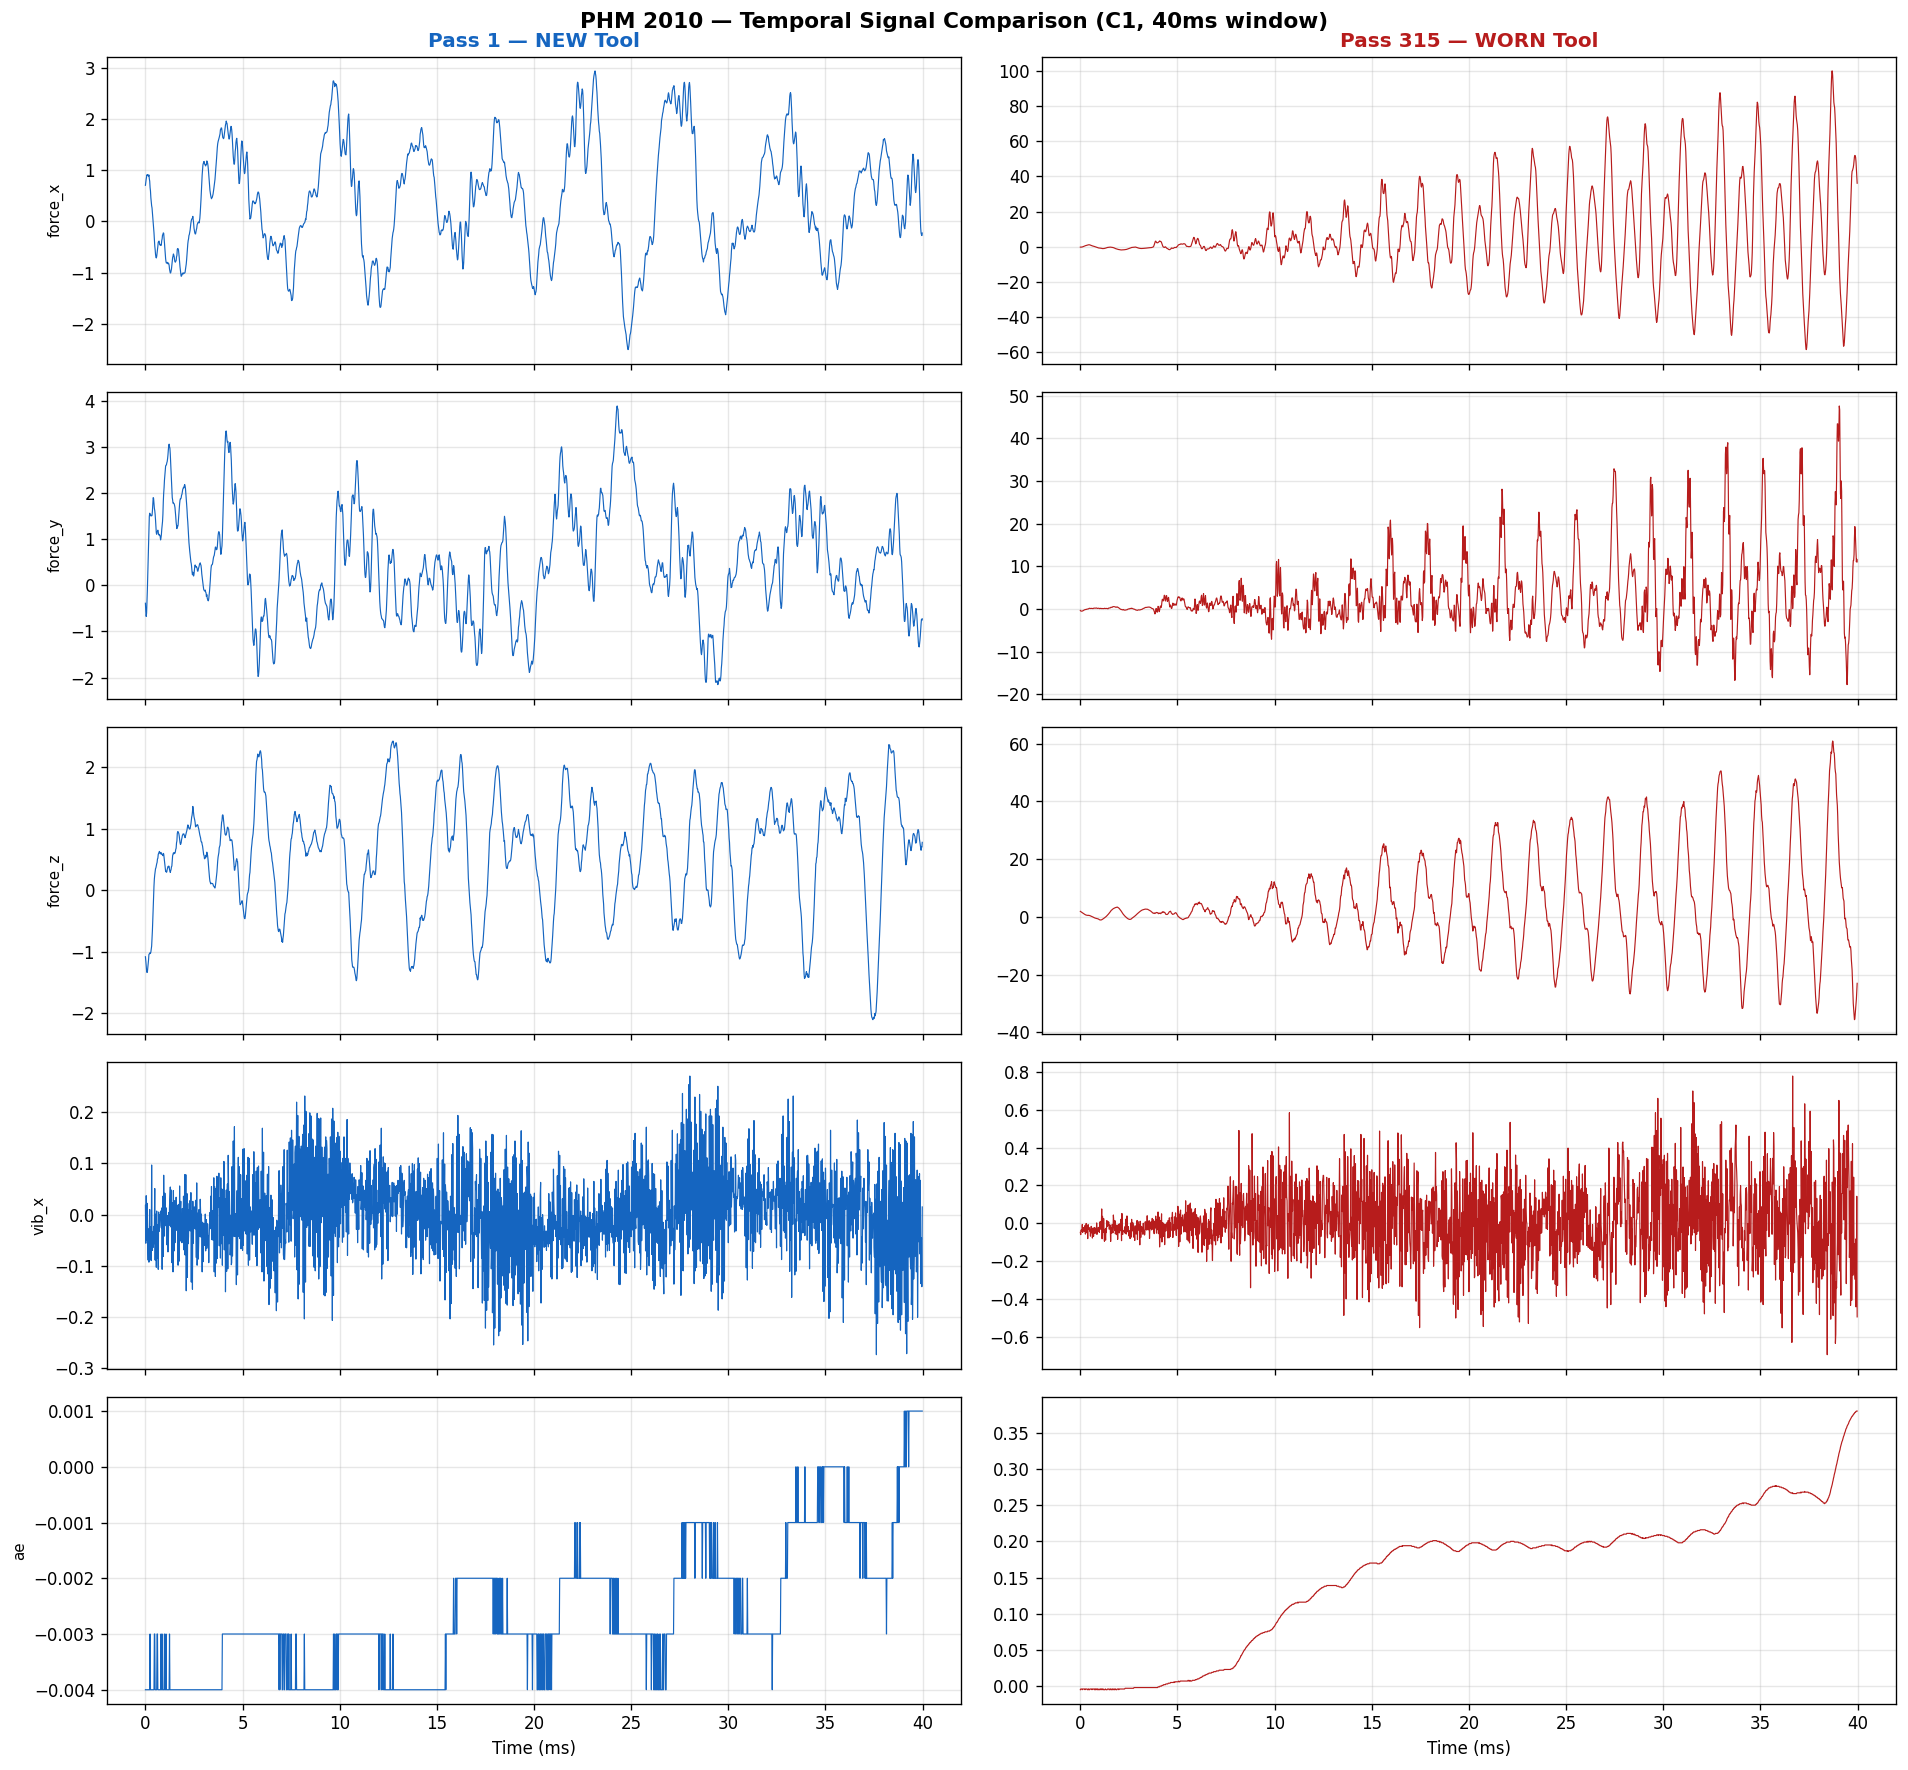

force_x    | RMS new=0.9330  worn=46.8542  ratio=50.22x
force_y    | RMS new=1.7529  worn=21.9802  ratio=12.54x
ae         | RMS new=0.0022  worn=0.2333  ratio=104.58x


In [4]:
files_c1 = sorted([f for f in glob.glob(os.path.join(DATASET_PATH, 'c1', '**', '*.csv'), recursive=True) if 'wear' not in f.lower()])
if len(files_c1) < 2:
    print('No C1 files found — check DATASET_PATH'); 
else:
    sig_new  = load_signal(files_c1[0])    # Pass 1  → new tool
    sig_worn = load_signal(files_c1[-1])   # Last pass → worn tool

    n_show = int(0.04 * FS)   # 40 ms window
    t_ms   = np.arange(n_show) / FS * 1000
    channels_show = ['force_x', 'force_y', 'force_z', 'vib_x', 'ae']

    fig, axes = plt.subplots(len(channels_show), 2,
                              figsize=(16, 3*len(channels_show)),
                              sharex=True)

    for i, ch in enumerate(channels_show):
        axes[i,0].plot(t_ms, sig_new[ch].values[:n_show],
                       color='#1565C0', linewidth=0.7)
        axes[i,0].set_ylabel(ch, fontsize=9)
        axes[i,0].grid(True, alpha=0.3)
        if i == 0: axes[i,0].set_title('Pass 1 — NEW Tool', fontweight='bold', color='#1565C0')

        axes[i,1].plot(t_ms, sig_worn[ch].values[:n_show],
                       color='#B71C1C', linewidth=0.7)
        axes[i,1].grid(True, alpha=0.3)
        if i == 0: axes[i,1].set_title(f'Pass {len(files_c1)} — WORN Tool', fontweight='bold', color='#B71C1C')

    for ax in axes[-1]: ax.set_xlabel('Time (ms)')
    plt.suptitle('PHM 2010 — Temporal Signal Comparison (C1, 40ms window)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Summary stats
    for ch in ['force_x', 'force_y', 'ae']:
        rms_new  = np.sqrt(np.mean(sig_new[ch]**2))
        rms_worn = np.sqrt(np.mean(sig_worn[ch]**2))
        print(f'{ch:10s} | RMS new={rms_new:.4f}  worn={rms_worn:.4f}  ratio={rms_worn/rms_new:.2f}x')

## 4. Spectral Analysis (FFT & Welch PSD)

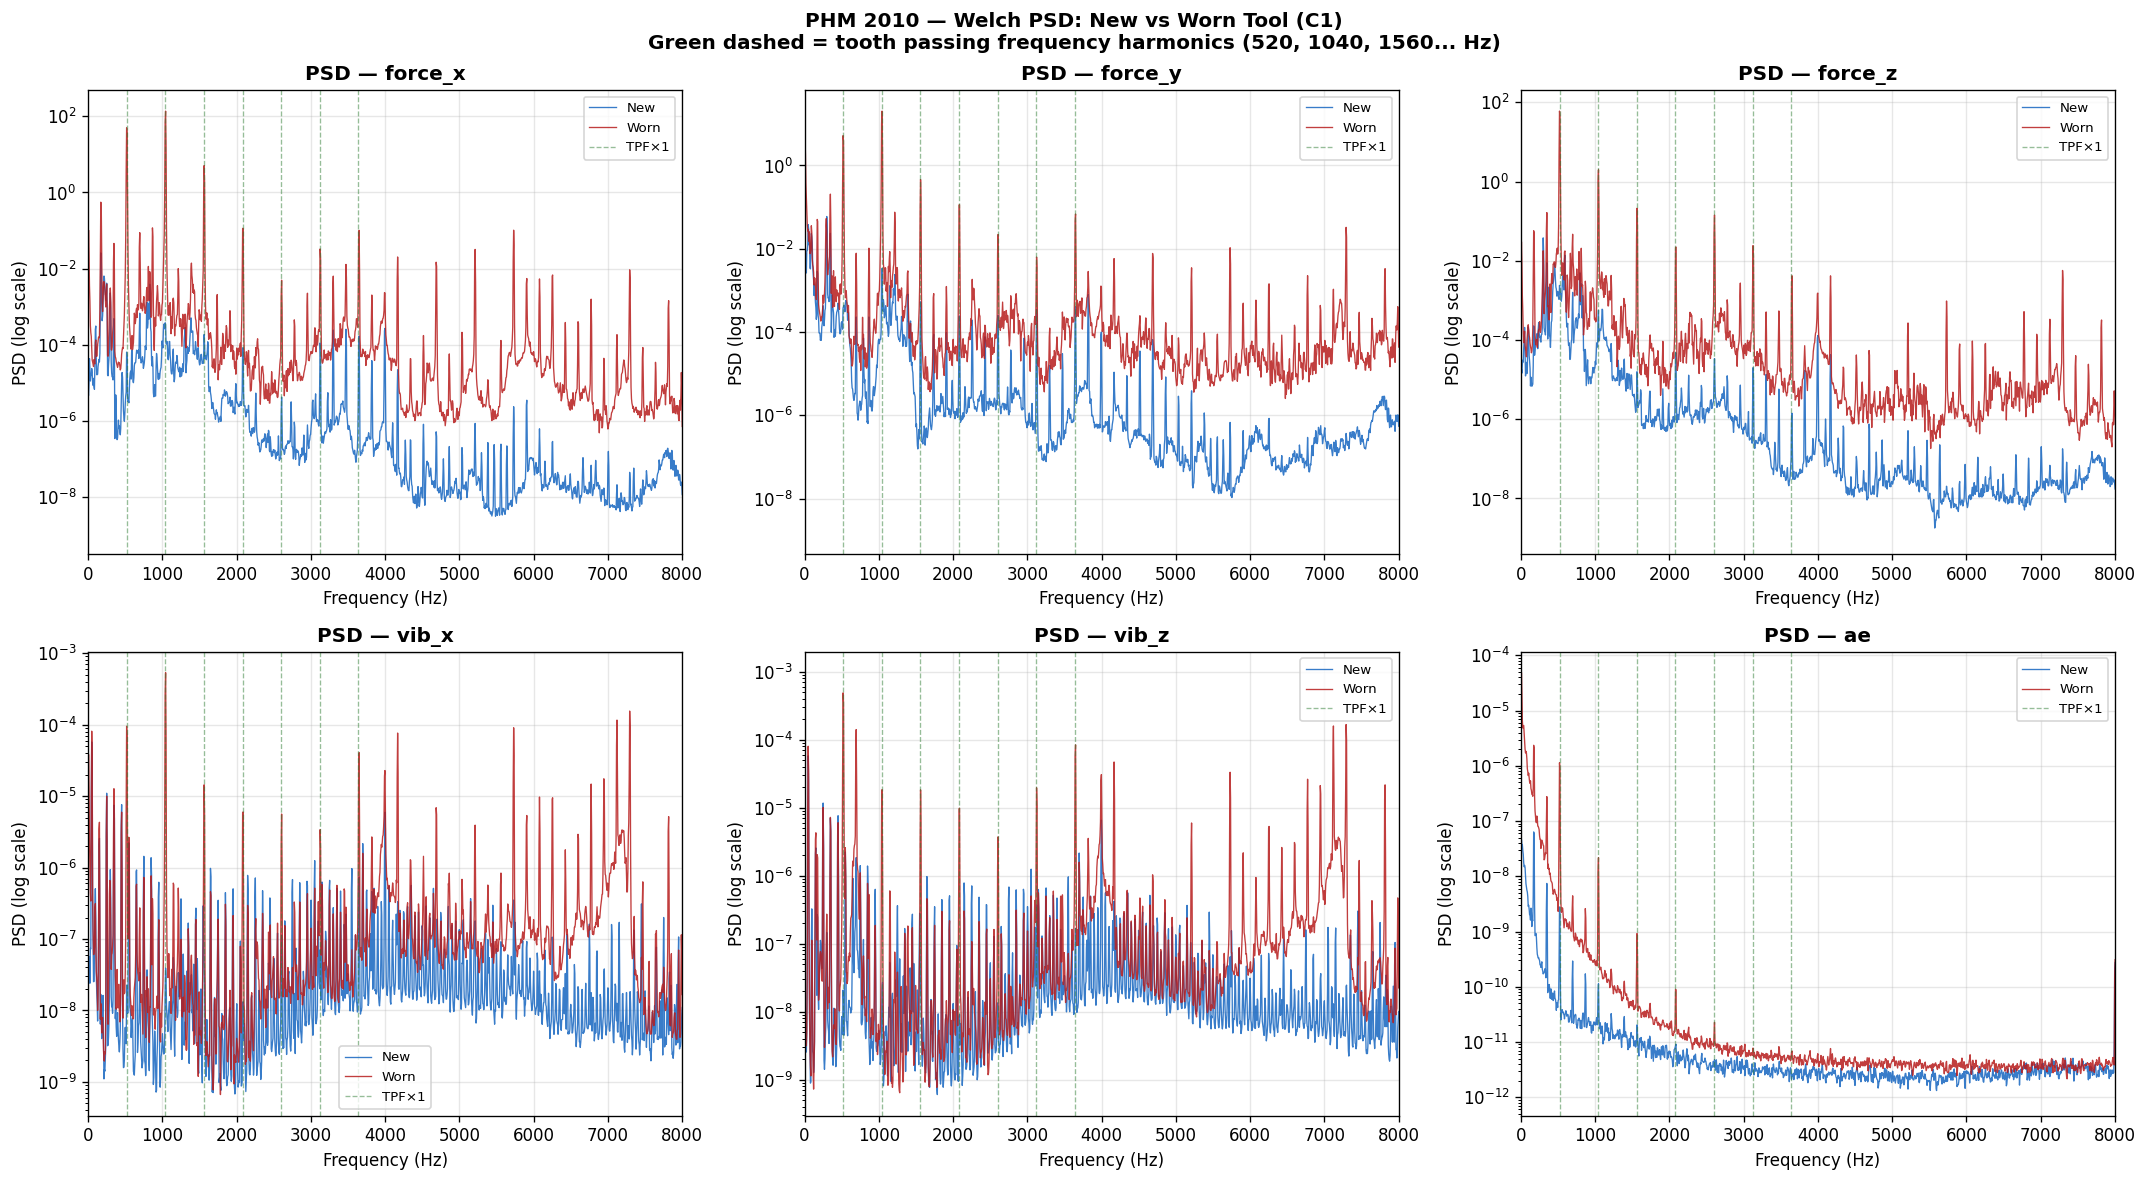

In [5]:
if 'sig_new' in dir():
    def welch_psd(sig, fs=FS, nperseg=8192):
        return welch(sig, fs=fs, nperseg=nperseg)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    channels_fft = ['force_x', 'force_y', 'force_z', 'vib_x', 'vib_z', 'ae']

    for idx, ch in enumerate(channels_fft):
        ax = axes[idx // 3][idx % 3]
        f_n, p_n = welch_psd(sig_new[ch].values)
        f_w, p_w = welch_psd(sig_worn[ch].values)

        ax.semilogy(f_n, p_n, color='#1565C0', linewidth=0.8, alpha=0.85, label='New')
        ax.semilogy(f_w, p_w, color='#B71C1C', linewidth=0.8, alpha=0.85, label='Worn')

        # Mark tooth pass frequency harmonics
        for h in range(1, 8):
            freq_h = F_TOOTH * h
            if freq_h < FS/2:
                ax.axvline(freq_h, color='#2E7D32', linestyle='--',
                           alpha=0.5, linewidth=0.8,
                           label=f'TPF×{h}' if h == 1 else None)

        ax.set_title(f'PSD — {ch}', fontweight='bold')
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('PSD (log scale)')
        ax.set_xlim([0, 8000])
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle('PHM 2010 — Welch PSD: New vs Worn Tool (C1)\n'
                 'Green dashed = tooth passing frequency harmonics (520, 1040, 1560... Hz)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 5. Feature Extraction (Time + Frequency Domains)

In [ ]:
FREQ_BANDS = [(0, 200), (200, 600), (600, 1500), (1500, 4000), (4000, 10000)]

def extract_features(df_sig, fs=FS):
    feats = {}
    for col in COL_NAMES:
        sig = df_sig[col].values.astype(np.float64)
        mu  = np.mean(sig)
        sig_centered = sig - mu
        rms = np.sqrt(np.mean(sig**2))

        # Time-domain features
        feats[f'{col}_mean']   = mu
        feats[f'{col}_std']    = np.std(sig)
        feats[f'{col}_rms']    = rms
        feats[f'{col}_peak']   = np.max(np.abs(sig))
        feats[f'{col}_p2p']    = np.ptp(sig)
        feats[f'{col}_kurt']   = kurtosis(sig)
        feats[f'{col}_skew']   = skew(sig)
        feats[f'{col}_crest']  = feats[f'{col}_peak'] / (rms + 1e-12)
        feats[f'{col}_shape']  = rms / (np.mean(np.abs(sig)) + 1e-12)
        feats[f'{col}_energy'] = np.sum(sig**2) / len(sig)
        feats[f'{col}_p25']    = np.percentile(sig, 25)
        feats[f'{col}_p75']    = np.percentile(sig, 75)
        feats[f'{col}_iqr']    = feats[f'{col}_p75'] - feats[f'{col}_p25']

        # Frequency-domain features (Welch PSD)
        f_ax, pxx = welch(sig, fs=fs, nperseg=4096)
        total_pwr = np.sum(pxx) + 1e-12
        for f_lo, f_hi in FREQ_BANDS:
            mask = (f_ax >= f_lo) & (f_ax < f_hi)
            feats[f'{col}_band_{f_lo}_{f_hi}']     = np.sum(pxx[mask])
            feats[f'{col}_band_{f_lo}_{f_hi}_rel'] = np.sum(pxx[mask]) / total_pwr

        # Tooth pass frequency energy
        for h in range(1, 6):
            tpf_h = F_TOOTH * h
            mask_tpf = (f_ax >= tpf_h - 30) & (f_ax <= tpf_h + 30)
            feats[f'{col}_tpf_h{h}'] = np.sum(pxx[mask_tpf])

    return feats

print('⏳ Extracting features from all labeled files...')
rows = []
for tool in TOOLS_LABELED:
    files = sorted([f for f in glob.glob(os.path.join(DATASET_PATH, tool, '**', '*.csv'), recursive=True) if 'wear' not in f.lower()])
    df_w  = wear.get(tool)
    if df_w is None: continue
    for fp in files:
        passe = int(os.path.basename(fp).replace('.csv','').split('_')[-1])
        vb_row = df_w[df_w['passe'] == passe]
        if vb_row.empty: continue
        try:
            df_sig = load_signal(fp)
            feats  = extract_features(df_sig)
            vb     = float(vb_row['vb_mean'].values[0])
            feats.update({'tool': tool, 'passe': passe, 'vb': vb,
                          'etat': 'new' if vb < 0.1 else
                                  ('ok' if vb < 0.2 else ('worn' if vb < 0.3 else 'eol'))})
            rows.append(feats)
        except: pass

df_feat = pd.DataFrame(rows)
df_feat.to_csv('phm2010_features.csv', index=False)
print(f'✅ {df_feat.shape[0]} samples × {df_feat.shape[1]} columns')
print(f'   Wear class distribution: {df_feat["etat"].value_counts().to_dict()}')

⏳ Extracting features from all labeled files...


## 6. Feature Evolution over Passes

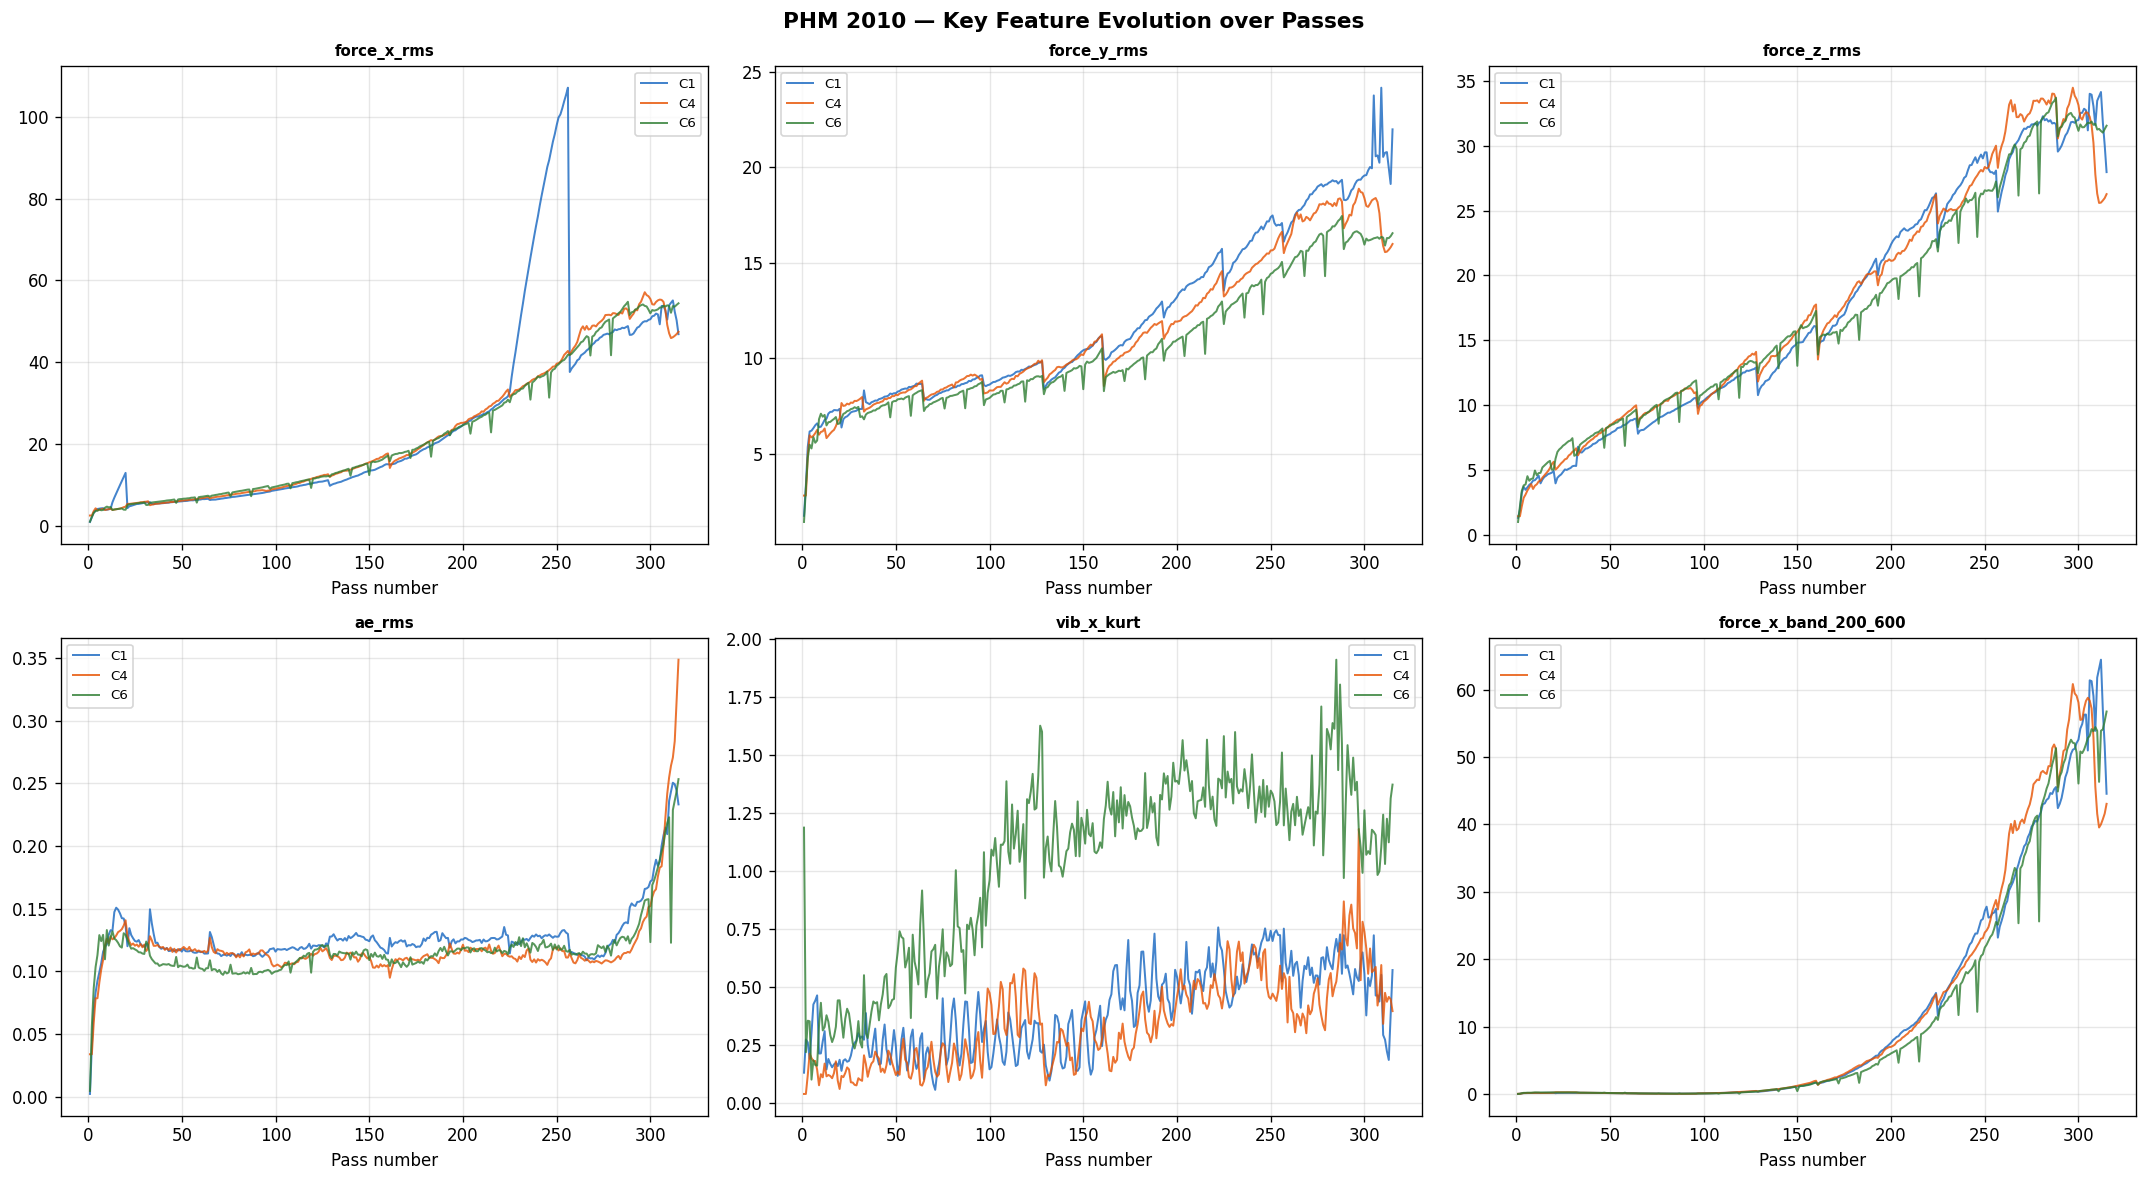

In [ ]:
key_features = ['force_x_rms', 'force_y_rms', 'force_z_rms',
                 'ae_rms', 'vib_x_kurt', 'force_x_band_200_600']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, feat in enumerate(key_features):
    ax = axes[idx // 3][idx % 3]
    if feat not in df_feat.columns:
        ax.text(0.5, 0.5, f'{feat}\nnot found', ha='center', va='center', transform=ax.transAxes)
        continue
    for t in TOOLS_LABELED:
        sub = df_feat[df_feat['tool'] == t].sort_values('passe')
        if sub.empty: continue
        ax.plot(sub['passe'], sub[feat], color=COLORS[t], label=t.upper(),
                linewidth=1.2, alpha=0.8)
    ax.set_title(feat, fontweight='bold', fontsize=9)
    ax.set_xlabel('Pass number')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('PHM 2010 — Key Feature Evolution over Passes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Correlation Analysis

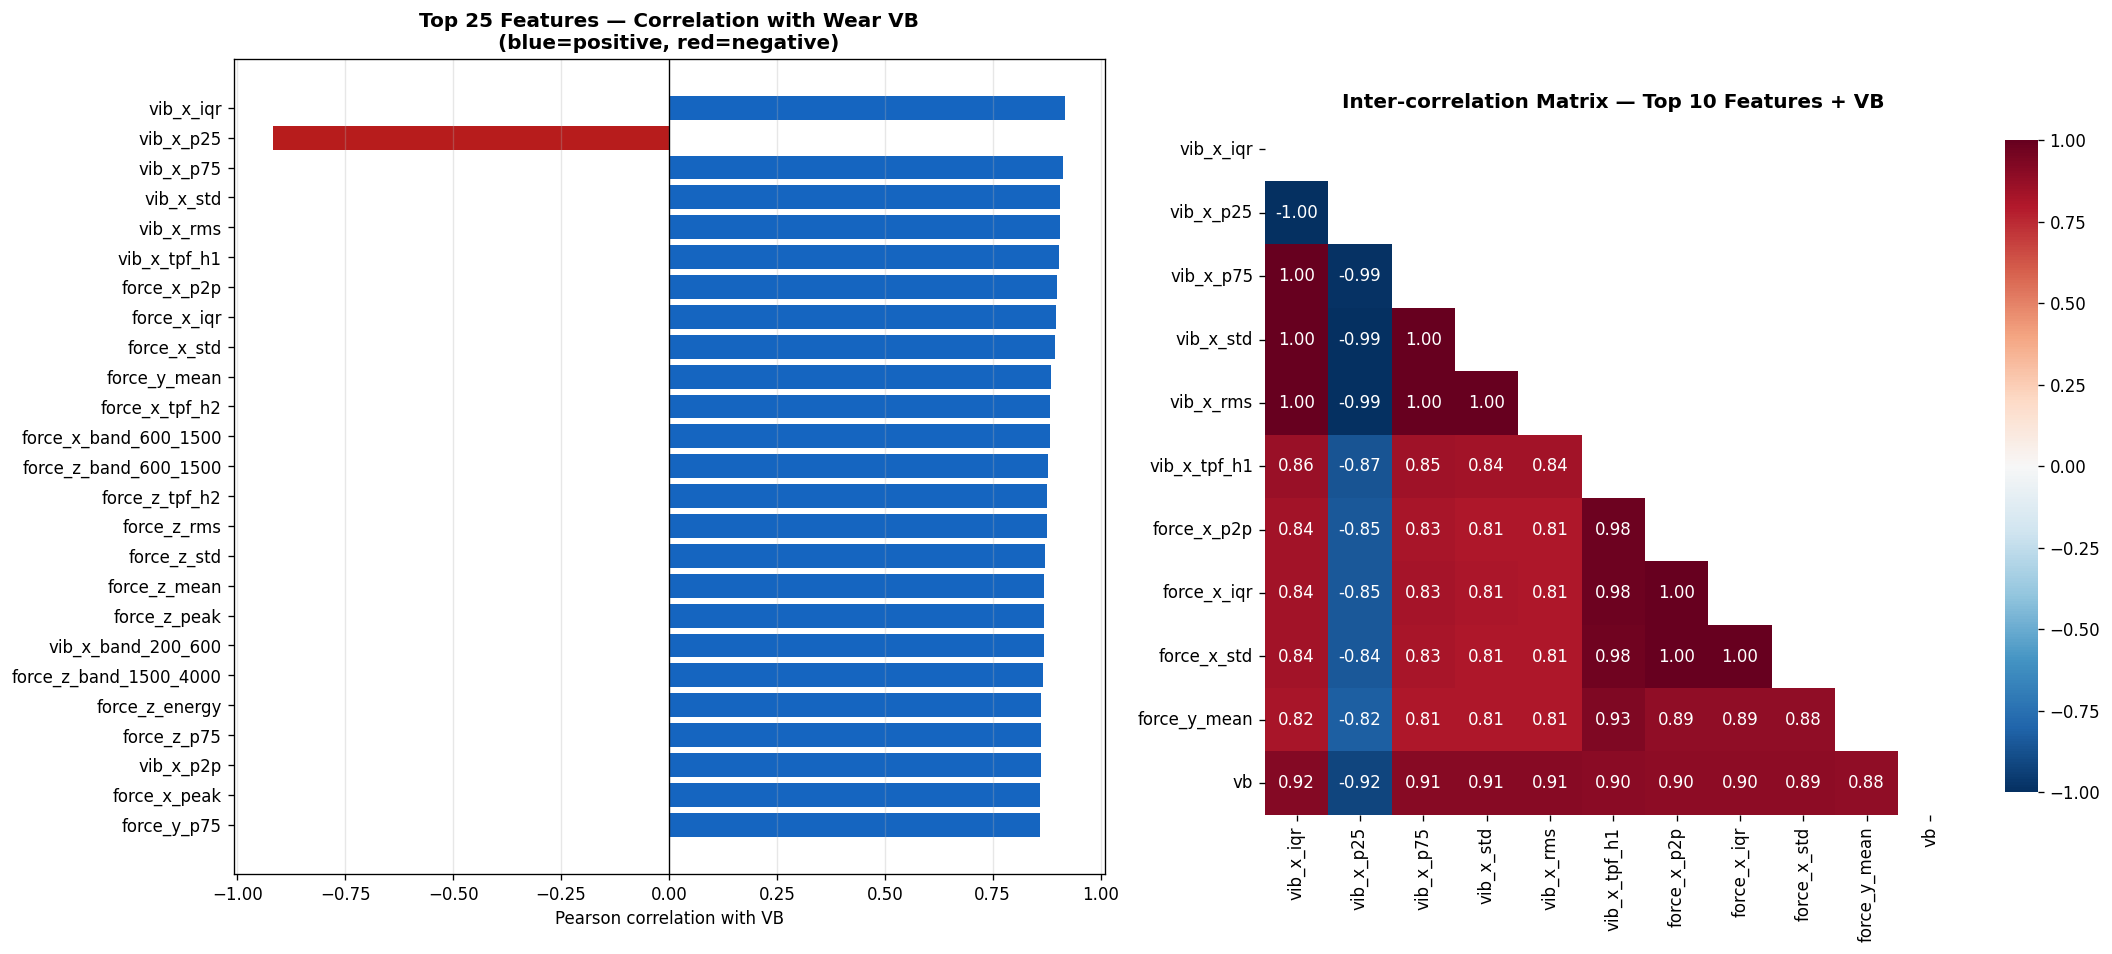

Top 5 positively correlated features with VB:
vib_x_iqr       0.9178
vib_x_p75       0.9124
vib_x_std       0.9067
vib_x_rms       0.9064
vib_x_tpf_h1    0.9044
Name: vb, dtype: float64

Top 5 negatively correlated features with VB:
vib_x_p25                  -0.9171
vib_z_p25                  -0.8272
vib_x_tpf_h5               -0.8009
vib_x_band_1500_4000_rel   -0.7873
force_z_p25                -0.7846
Name: vb, dtype: float64


In [ ]:
feat_cols = [c for c in df_feat.columns if c not in ['tool','passe','vb','etat']]

corr_vb = df_feat[feat_cols + ['vb']].corr()['vb'].drop('vb')
top25   = corr_vb.abs().nlargest(25)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Bar chart of top 25
bar_colors = ['#1565C0' if corr_vb[f] > 0 else '#B71C1C' for f in top25.index]
axes[0].barh(top25.index[::-1], corr_vb[top25.index[::-1]], color=bar_colors[::-1])
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Pearson correlation with VB')
axes[0].set_title('Top 25 Features — Correlation with Wear VB\n(blue=positive, red=negative)',
                   fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Heatmap for top 10 features inter-correlation
top10_names = list(top25.index[:10]) + ['vb']
top10_names = [c for c in top10_names if c in df_feat.columns]
corr_sub = df_feat[top10_names].corr()
mask = np.triu(np.ones_like(corr_sub, dtype=bool))
sns.heatmap(corr_sub, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=axes[1], square=True,
            cbar_kws={'shrink': 0.8})
axes[1].set_title('Inter-correlation Matrix — Top 10 Features + VB', fontweight='bold')

plt.tight_layout()
plt.show()

print('Top 5 positively correlated features with VB:')
print(corr_vb.nlargest(5).round(4))
print('\nTop 5 negatively correlated features with VB:')
print(corr_vb.nsmallest(5).round(4))

## 8. ML Model — Leave-One-Tool-Out Validation

  c1: MAE=0.0218 mm | RMSE=0.0319 mm | R²=-0.368
  c4: MAE=0.0195 mm | RMSE=0.0239 mm | R²=0.604
  c6: MAE=0.0220 mm | RMSE=0.0235 mm | R²=0.655


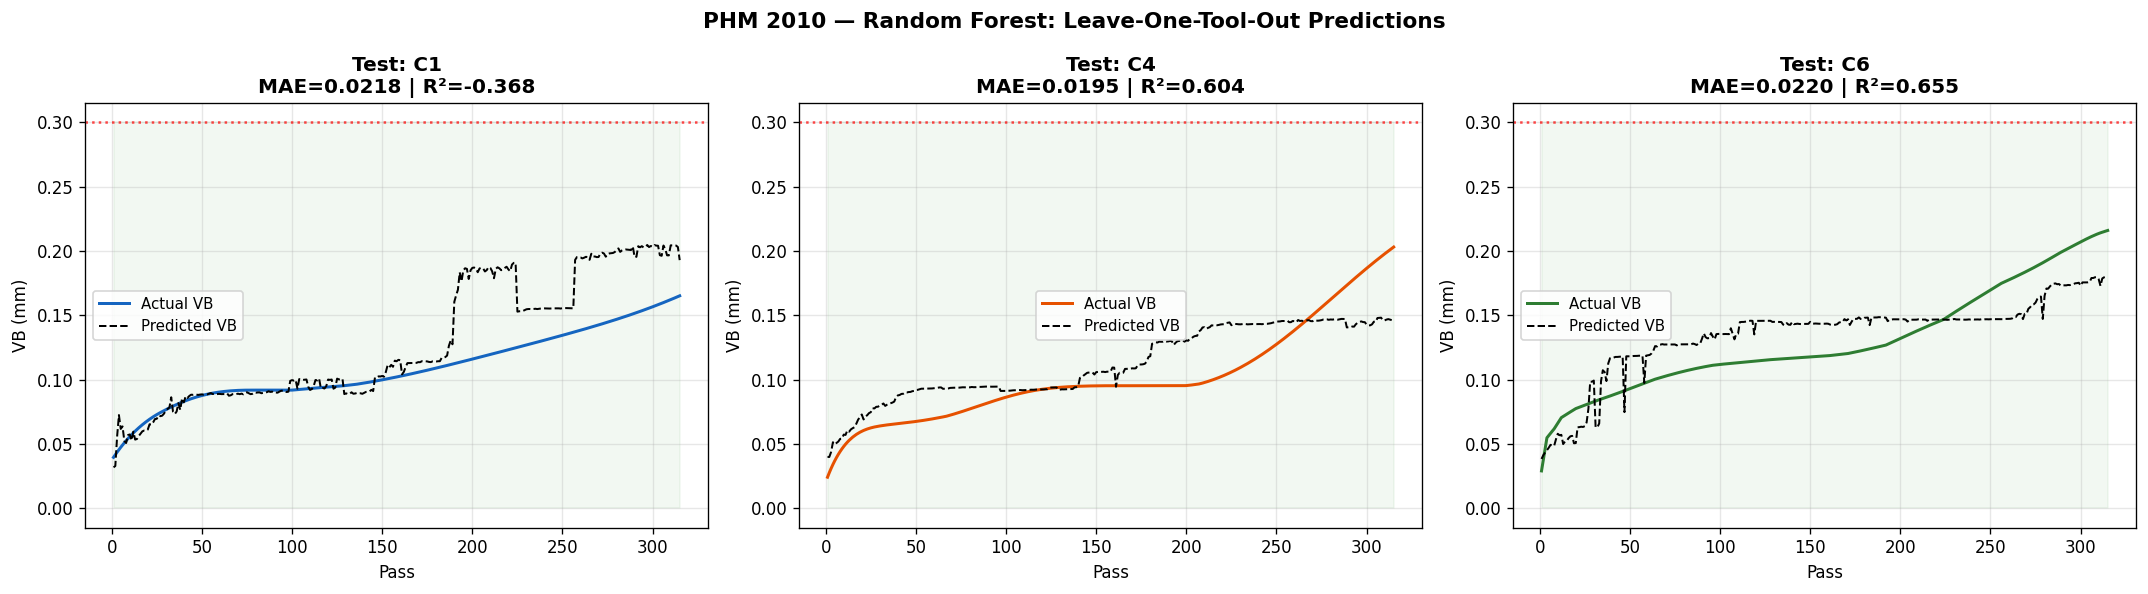

,Test tool,MAE (mm),RMSE (mm),R²
0,C1,0.0218,0.0319,-0.368
1,C4,0.0195,0.0239,0.604
2,C6,0.0220,0.0235,0.655


In [ ]:
import math

X      = df_feat[feat_cols].fillna(0).values
y      = df_feat['vb'].values
groups = df_feat['tool'].values

logo  = LeaveOneGroupOut()
model = RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)

fig, axes = plt.subplots(1, len(TOOLS_LABELED), figsize=(6*len(TOOLS_LABELED), 5))
results = []

for i, (tr_idx, te_idx) in enumerate(logo.split(X, y, groups)):
    test_tool = np.unique(groups[te_idx])[0]
    model.fit(X[tr_idx], y[tr_idx])
    y_pred = model.predict(X[te_idx])
    y_true = y[te_idx]

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    results.append({'Test tool': test_tool.upper(), 'MAE (mm)': round(mae, 4),
                    'RMSE (mm)': round(rmse, 4), 'R²': round(r2, 3)})

    passes_te = df_feat.iloc[te_idx]['passe'].values
    sidx      = np.argsort(passes_te)
    ax = axes[i] if len(TOOLS_LABELED) > 1 else axes
    ax.plot(passes_te[sidx], y_true[sidx], color=COLORS[test_tool],
            linewidth=1.8, label='Actual VB')
    ax.plot(passes_te[sidx], y_pred[sidx], color='black',
            linewidth=1.2, linestyle='--', label='Predicted VB')
    ax.axhline(VB_EOL,  color='red',    linestyle=':', alpha=0.7)
    ax.fill_between(passes_te[sidx],
                    np.zeros_like(passes_te[sidx]), VB_EOL,
                    alpha=0.05, color='green')
    ax.set_title(f'Test: {test_tool.upper()}\nMAE={mae:.4f} | R²={r2:.3f}',
                 fontweight='bold')
    ax.set_xlabel('Pass'); ax.set_ylabel('VB (mm)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    print(f'  {test_tool}: MAE={mae:.4f} mm | RMSE={rmse:.4f} mm | R²={r2:.3f}')

plt.suptitle('PHM 2010 — Random Forest: Leave-One-Tool-Out Predictions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

df_results = pd.DataFrame(results)
display(df_results)

## 9. Feature Importance

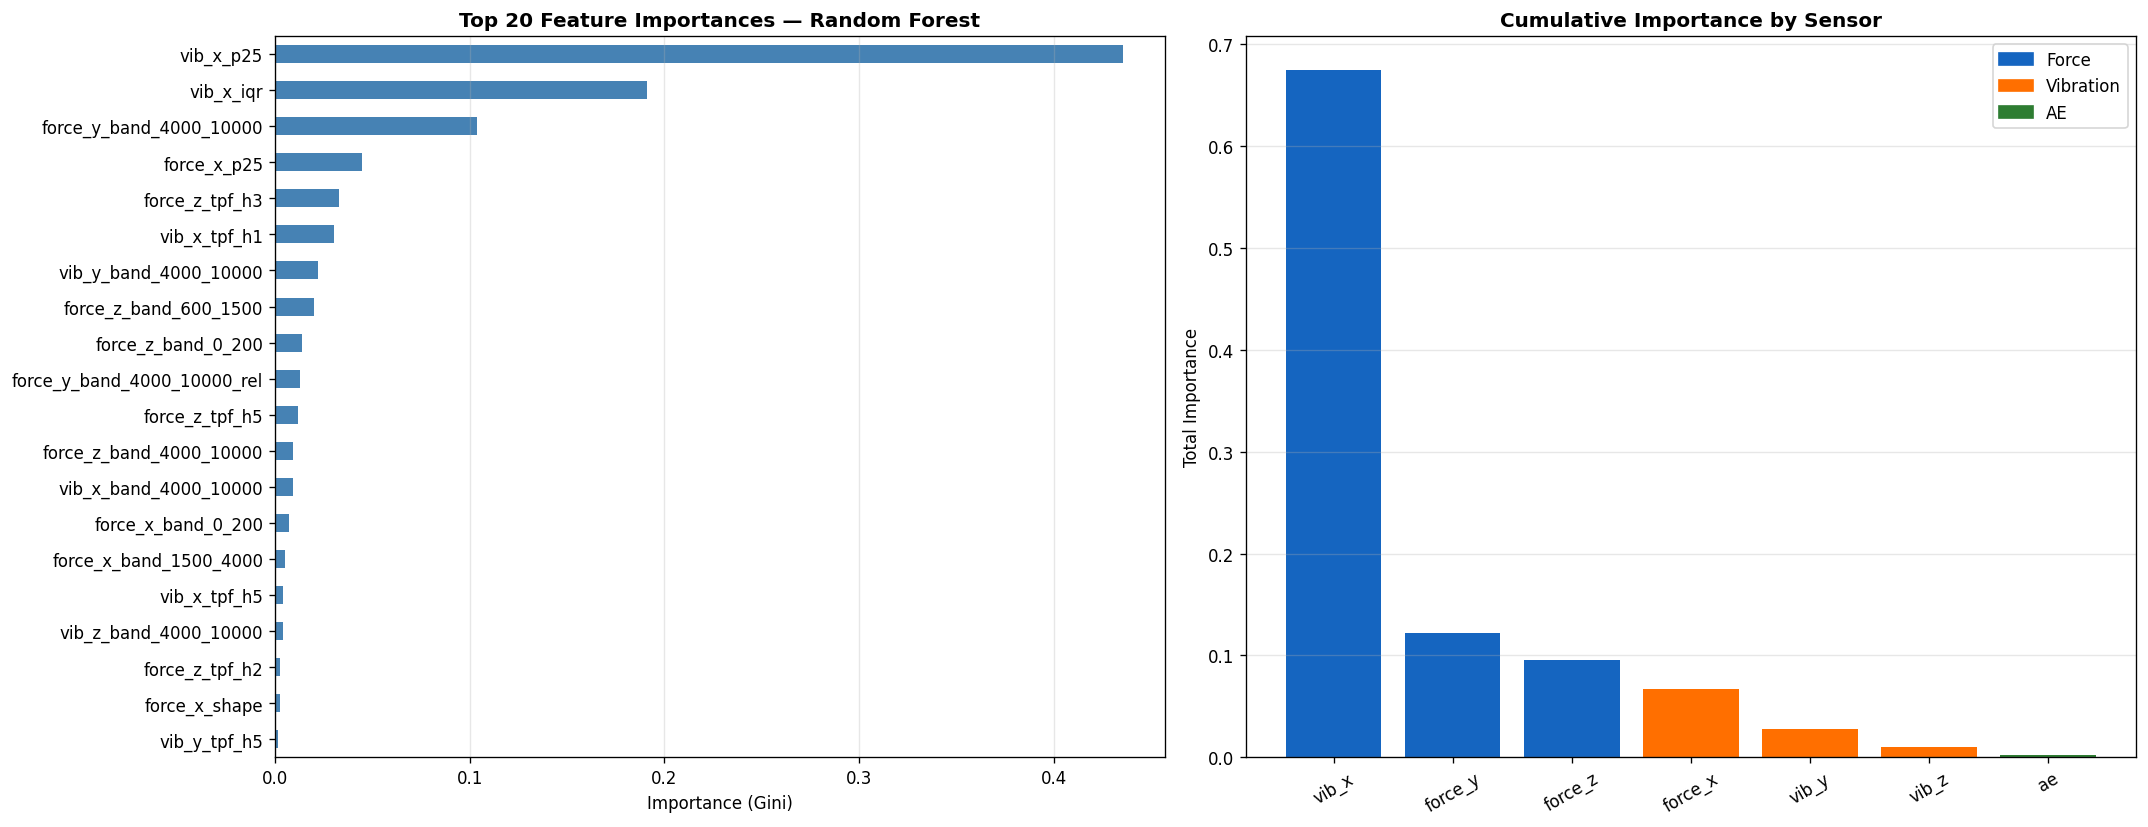

In [ ]:
model.fit(X, y)
imp = pd.Series(model.feature_importances_, index=feat_cols)
top20 = imp.nlargest(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Overall importance
top20[::-1].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Feature Importances — Random Forest', fontweight='bold')
axes[0].set_xlabel('Importance (Gini)')
axes[0].grid(True, alpha=0.3, axis='x')

# By sensor group
sensor_groups = {s: imp[[c for c in feat_cols if c.startswith(s)]].sum()
                 for s in ['force_x','force_y','force_z','vib_x','vib_y','vib_z','ae']}
sg_series = pd.Series(sensor_groups).sort_values(ascending=False)
axes[1].bar(sg_series.index, sg_series.values,
            color=['#1565C0','#1565C0','#1565C0','#FF6F00','#FF6F00','#FF6F00','#2E7D32'])
axes[1].set_title('Cumulative Importance by Sensor', fontweight='bold')
axes[1].set_ylabel('Total Importance')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, alpha=0.3, axis='y')
from matplotlib.patches import Patch
legend_items = [Patch(color='#1565C0', label='Force'),
                Patch(color='#FF6F00', label='Vibration'),
                Patch(color='#2E7D32', label='AE')]
axes[1].legend(handles=legend_items)

plt.tight_layout()
plt.show()

## 10. Summary Statistics

In [ ]:
print('=' * 55)
print('PHM 2010 DATASET — ANALYSIS SUMMARY')
print('=' * 55)
print(f'Total labeled samples     : {len(df_feat)}')
print(f'Total features extracted  : {len(feat_cols)}')
print(f'  Time-domain features    : {len([c for c in feat_cols if any(k in c for k in ["mean","std","rms","peak","kurt","skew","crest","p25","p75","iqr","energy","p2p","shape"])])}')
print(f'  Frequency-domain feat.  : {len([c for c in feat_cols if "band" in c or "tpf" in c])}')
print()
print('VB range per tool:')
for t, df_w in wear.items():
    print(f'  {t.upper()}: {df_w["vb_mean"].min():.3f} → {df_w["vb_mean"].max():.3f} mm '
          f'({len(df_w)} passes)')
print()
print('ML Results (Leave-One-Tool-Out):')
display(df_results)
print(f'\nBest correlated feature with VB: {corr_vb.abs().idxmax()} (r={corr_vb.abs().max():.3f})')

PHM 2010 DATASET — ANALYSIS SUMMARY
Total labeled samples     : 945
Total features extracted  : 196
  Time-domain features    : 91
  Frequency-domain feat.  : 105

VB range per tool:
  C1: 0.040 → 0.165 mm (315 passes)
  C4: 0.024 → 0.203 mm (315 passes)
  C6: 0.029 → 0.216 mm (315 passes)

ML Results (Leave-One-Tool-Out):


,Test tool,MAE (mm),RMSE (mm),R²
0,C1,0.0218,0.0319,-0.368
1,C4,0.0195,0.0239,0.604
2,C6,0.0220,0.0235,0.655



Best correlated feature with VB: vib_x_iqr (r=0.918)
